# Examen Aplicado de Machine Learning I
* **Nombre del Dataset:** California Housing Dataset
* **Fuente:** Scikit-Learn / StatLib (Pace, R. Kelley and Ronald Barry, 1997)
* **URL:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html
* **Número de Filas:** 20.640
* **Número de Columnas:** 9 (8 predictoras + 1 objetivo)
* **Variable Objetivo:** `MedHouseVal` (Valor medio de la vivienda en distritos de California, expresado en cientos de miles de USD)
* **Tipo de Tarea:** Regresión

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
os.makedirs('figures', exist_ok=True)

In [2]:
# Carga del dataset oficial desde scikit-learn
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print("=== DIMENSIONES (shape) ===")
print(df.shape)

print("\n=== TIPOS DE DATOS (dtypes) ===")
print(df.dtypes)

print("\n=== INFORMACIÓN GENERAL (info) ===")
df.info()

print("\n=== ESTADÍSTICAS DESCRIPTIVAS (describe) ===")
display(df.describe().T)

print("\n=== PRIMERAS 5 FILAS (head) ===")
df.head()

=== DIMENSIONES (shape) ===
(20640, 9)

=== TIPOS DE DATOS (dtypes) ===
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

=== INFORMACIÓN GENERAL (info) ===
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

=== ESTADÍSTICAS DESCRIPTIVAS (describe) ===


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010



=== PRIMERAS 5 FILAS (head) ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Resumen de Valores Nulos:
             Total_Nulos  Porcentaje_Nulos
MedInc                 0               0.0
HouseAge               0               0.0
AveRooms               0               0.0
AveBedrms              0               0.0
Population             0               0.0
AveOccup               0               0.0
Latitude               0               0.0
Longitude              0               0.0
MedHouseVal            0               0.0


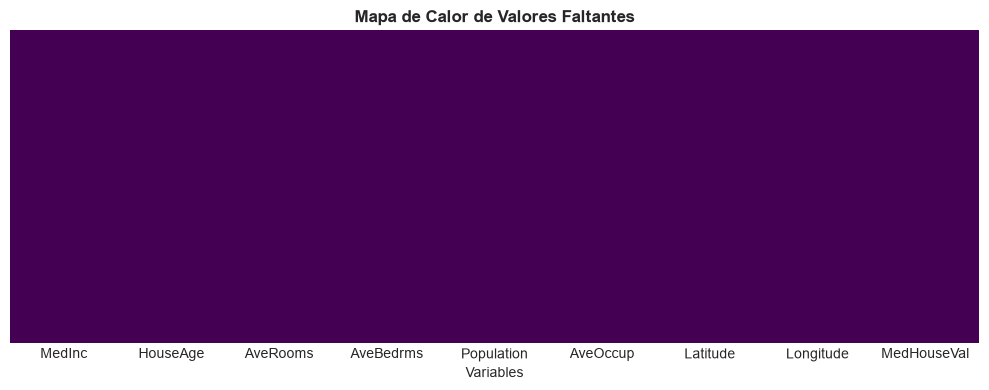

In [3]:
missing_summary = pd.DataFrame({
    'Total_Nulos': df.isnull().sum(),
    'Porcentaje_Nulos': (df.isnull().sum() / len(df)) * 100
})
print("Resumen de Valores Nulos:")
print(missing_summary)

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Mapa de Calor de Valores Faltantes", fontsize=12, fontweight='bold')
plt.xlabel("Variables")
plt.tight_layout()
plt.savefig('figures/01_missing_values_heatmap.png', dpi=150)
plt.show()

**Justificación del Tratamiento de Valores Faltantes:**
El dataset `California Housing` obtenido de Scikit-Learn se encuentra completamente limpio a nivel de consistencia estructural: presenta un 0.0% de valores nulos en todas sus columnas. No se requiere eliminar observaciones ni aplicar imputación estática en el DataFrame crudo para la exploración; sin embargo, en el pipeline de preprocesamiento se integrará `SimpleImputer(strategy='median')` como salvaguarda ante datos no vistos.

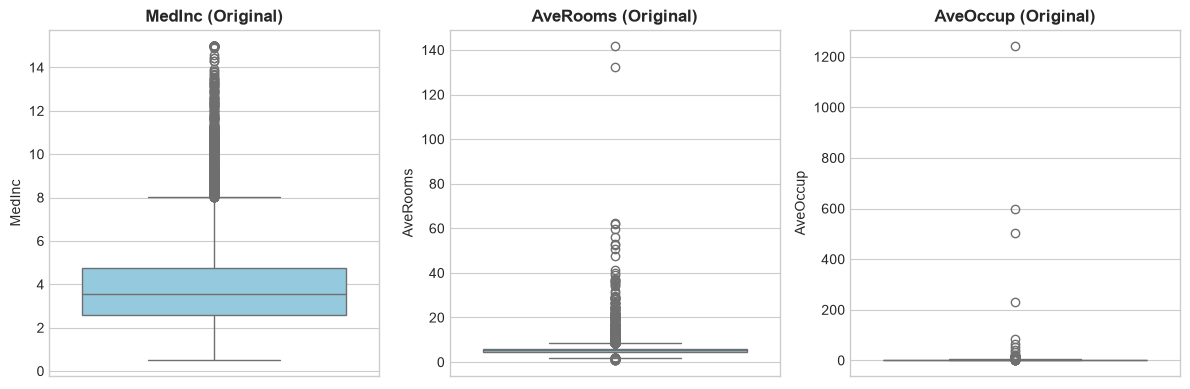

                Q1        Q3       IQR  Limite_Inferior  Limite_Superior  \
MedInc    2.563400  4.743250  2.179850        -0.706375         8.013025   
AveRooms  4.440716  6.052381  1.611665         2.023219         8.469878   
AveOccup  2.429741  3.282261  0.852520         1.150961         4.561041   

          Outliers_Count  Outliers_Pct  
MedInc             681.0      3.299419  
AveRooms           511.0      2.475775  
AveOccup           711.0      3.444767  


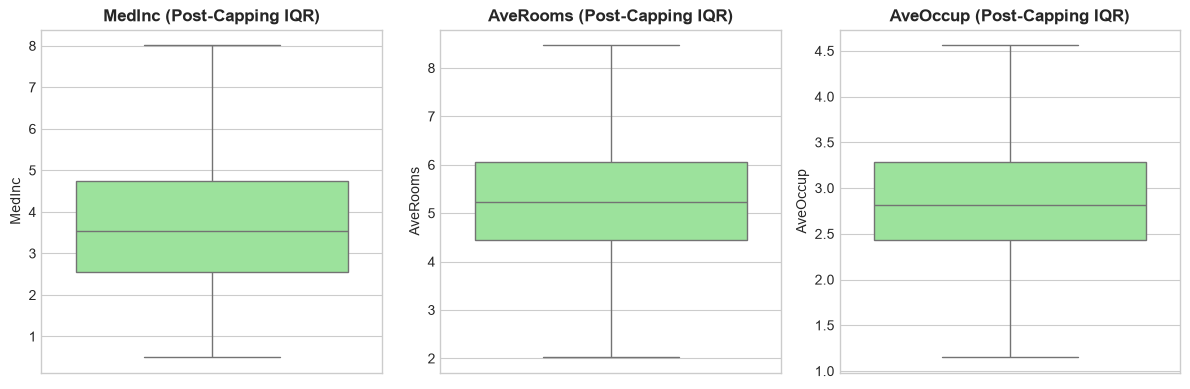

In [4]:
key_features = ['MedInc', 'AveRooms', 'AveOccup']

# Boxplots ANTES del tratamiento
plt.figure(figsize=(12, 4))
for i, col in enumerate(key_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col} (Original)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_boxplots_antes_iqr.png', dpi=150)
plt.show()

# Tratamiento por Capping (Winsorización por IQR) para preservar observaciones
df_treated = df.copy()
outlier_report = {}

for col in key_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_report[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Limite_Inferior': lower_bound, 'Limite_Superior': upper_bound,
        'Outliers_Count': n_outliers,
        'Outliers_Pct': (n_outliers / len(df)) * 100
    }
    # Capping a los límites IQR
    df_treated[col] = np.clip(df_treated[col], lower_bound, upper_bound)

print(pd.DataFrame(outlier_report).T)

# Boxplots DESPUÉS del tratamiento
plt.figure(figsize=(12, 4))
for i, col in enumerate(key_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_treated[col], color='lightgreen')
    plt.title(f'{col} (Post-Capping IQR)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_boxplots_despues_iqr.png', dpi=150)
plt.show()

**Justificación del Tratamiento de Outliers:**
Se detectaron valores extremos severos en `AveRooms` y `AveOccup` debido a distritos atípicos con promedios desproporcionados (ej. dormitorios comunes o residencias atípicas). En lugar de descartar filas completas —lo que distorsionaría la representatividad territorial de los distritos censales— se opta por recortar las colas extremas (*capping* o winsorización) a los límites $Q_1 - 1.5 \times IQR$ y $Q_3 + 1.5 \times IQR$, estabilizando la varianza sin perder volumen muestral.

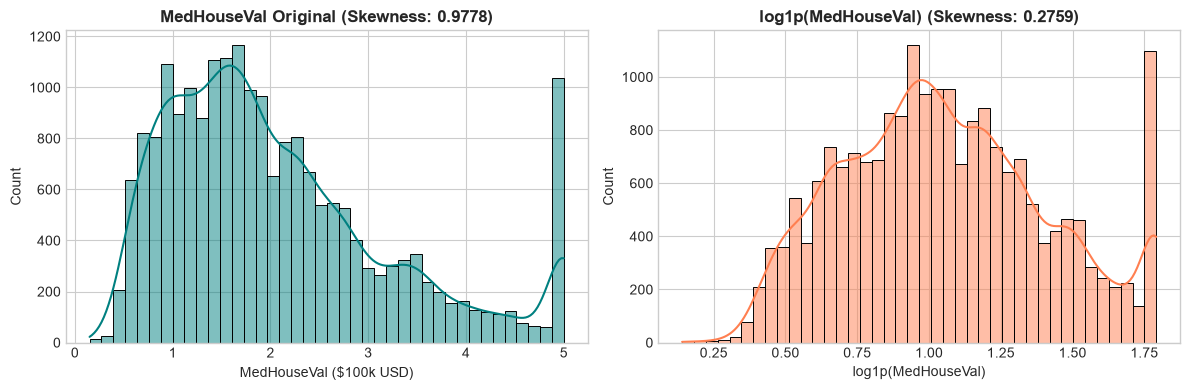

Skewness original: 0.9778
Skewness transformado log1p: 0.2759


In [5]:
target = 'MedHouseVal'
skew_orig = df[target].skew()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df[target], kde=True, color='teal', bins=40)
plt.title(f'{target} Original (Skewness: {skew_orig:.4f})', fontweight='bold')
plt.xlabel("MedHouseVal ($100k USD)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df[target]), kde=True, color='coral', bins=40)
skew_log = np.log1p(df[target]).skew()
plt.title(f'log1p({target}) (Skewness: {skew_log:.4f})', fontweight='bold')
plt.xlabel("log1p(MedHouseVal)")

plt.tight_layout()
plt.savefig('figures/04_target_distribution_skewness.png', dpi=150)
plt.show()

print(f"Skewness original: {skew_orig:.4f}")
print(f"Skewness transformado log1p: {skew_log:.4f}")

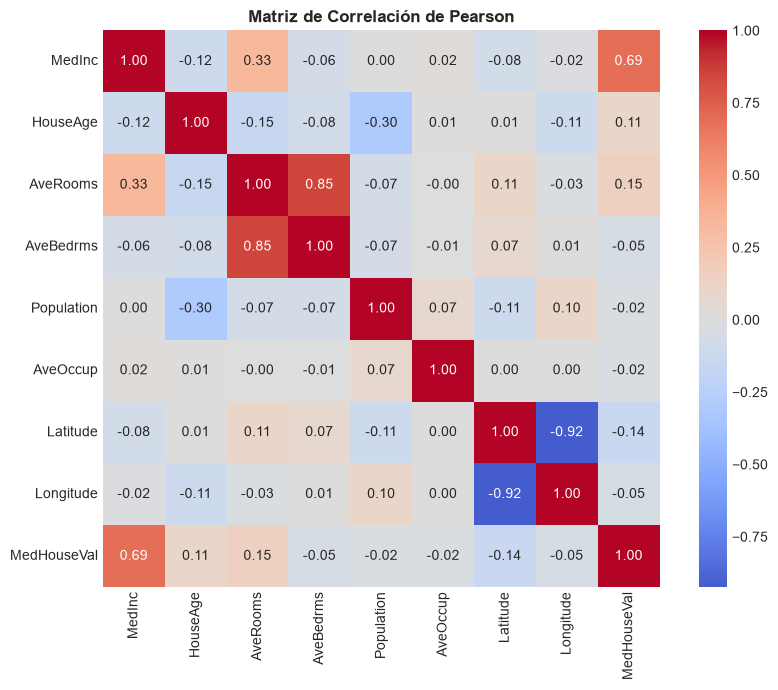

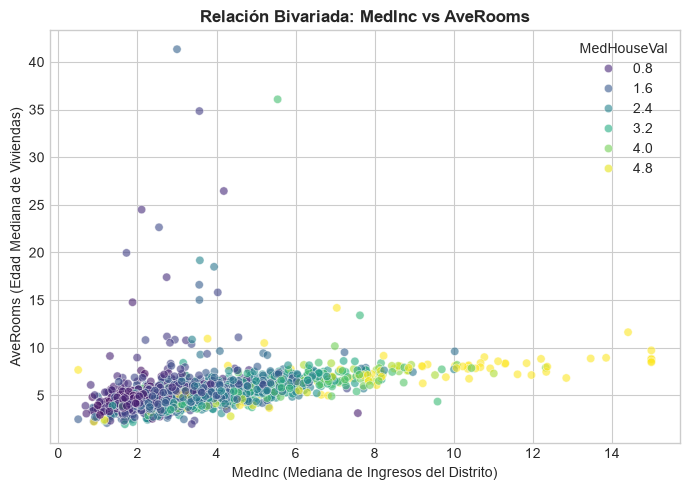

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_21412\314949036.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='HouseVal_Cat', y='MedInc', palette='Set2')


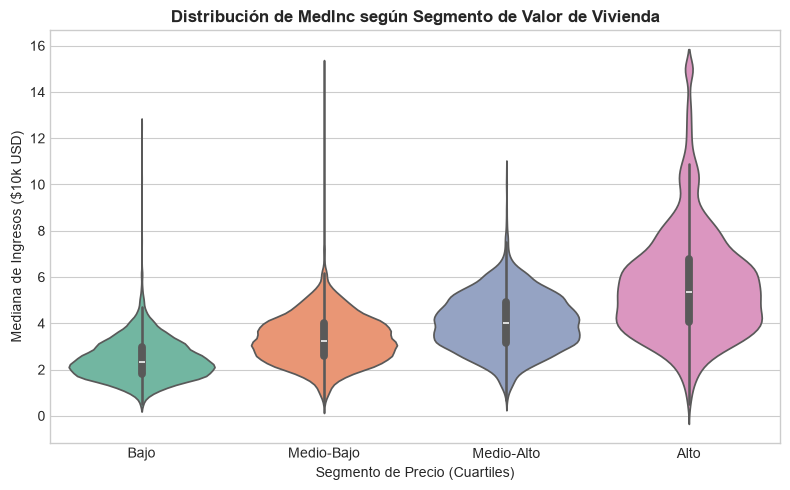

In [6]:
# 1. Heatmap de Correlación de Pearson
plt.figure(figsize=(9, 7))
corr_matrix = df.corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title("Matriz de Correlación de Pearson", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/05_correlation_heatmap.png', dpi=150)
plt.show()

# Identificar las dos variables más correlacionadas con la variable objetivo
top_2_corr = corr_matrix[target].abs().sort_values(ascending=False).iloc[1:3].index.tolist()

# 2. Scatter plot entre las dos variables más correlacionadas con MedHouseVal
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df.sample(2000, random_state=42), x=top_2_corr[0], y=top_2_corr[1], 
                hue=target, palette='viridis', alpha=0.6)
plt.title(f"Relación Bivariada: {top_2_corr[0]} vs {top_2_corr[1]}", fontweight='bold')
plt.xlabel(f"{top_2_corr[0]} (Mediana de Ingresos del Distrito)")
plt.ylabel(f"{top_2_corr[1]} (Edad Mediana de Viviendas)")
plt.tight_layout()
plt.savefig('figures/06_scatter_top_correlations.png', dpi=150)
plt.show()

# 3. Violin Plot: MedInc distribuido por cuartiles de MedHouseVal
df_violin = df.copy()
df_violin['HouseVal_Cat'] = pd.qcut(df_violin[target], q=4, labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'])
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_violin, x='HouseVal_Cat', y='MedInc', palette='Set2')
plt.title("Distribución de MedInc según Segmento de Valor de Vivienda", fontweight='bold')
plt.xlabel("Segmento de Precio (Cuartiles)")
plt.ylabel("Mediana de Ingresos ($10k USD)")
plt.tight_layout()
plt.savefig('figures/07_violin_medinc_by_target.png', dpi=150)
plt.show()

In [7]:
target_corr = corr_matrix[target].abs().sort_values(ascending=False)
top_5_target = target_corr.iloc[1:6]

print("=== TOP 5 VARIABLES MÁS CORRELACIONADAS CON MedHouseVal (|r|) ===")
for feat, val in top_5_target.items():
    print(f"* {feat}: {val:.4f} (Correlación real: {corr_matrix.loc[feat, target]:.4f})")

# Detección de multicolinealidad entre predictores (|r| > 0.85)
predictors_corr = corr_matrix.drop(index=target, columns=target)
multicollinear_pairs = []

for i in range(len(predictors_corr.columns)):
    for j in range(i + 1, len(predictors_corr.columns)):
        r = predictors_corr.iloc[i, j]
        if abs(r) > 0.85:
            multicollinear_pairs.append((predictors_corr.columns[i], predictors_corr.columns[j], r))

print("\n=== AUDITORÍA DE MULTICOLINEALIDAD (|r| > 0.85) ===")
if multicollinear_pairs:
    for f1, f2, r in multicollinear_pairs:
        print(f"Alerta: {f1} y {f2} presentan multicolinealidad severa con r = {r:.4f}")
else:
    print("No existen predictores con |r| > 0.85.")

=== TOP 5 VARIABLES MÁS CORRELACIONADAS CON MedHouseVal (|r|) ===
* MedInc: 0.6881 (Correlación real: 0.6881)
* AveRooms: 0.1519 (Correlación real: 0.1519)
* Latitude: 0.1442 (Correlación real: -0.1442)
* HouseAge: 0.1056 (Correlación real: 0.1056)
* AveBedrms: 0.0467 (Correlación real: -0.0467)

=== AUDITORÍA DE MULTICOLINEALIDAD (|r| > 0.85) ===
Alerta: Latitude y Longitude presentan multicolinealidad severa con r = -0.9247


In [8]:
from sklearn.model_selection import train_test_split

# 2.1 Partición de datos Train / Test (80% / 20%)
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Dimensiones X_train: {X_train.shape}")
print(f"Dimensiones X_test:  {X_test.shape}")
print(f"Dimensiones y_train: {y_train.shape}")
print(f"Dimensiones y_test:  {y_test.shape}")

Dimensiones X_train: (16512, 8)
Dimensiones X_test:  (4128, 8)
Dimensiones y_train: (16512,)
Dimensiones y_test:  (4128,)


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 2.2 Pipeline de Preprocesamiento sin Data Leakage
num_features = X_train.columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_features)
    ],
    remainder='drop'
)

# Ajuste solo en train; transformación en train y test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# DataFrames auxiliares estructurados
X_train_prep_df = pd.DataFrame(X_train_prep, columns=num_features, index=X_train.index)
X_test_prep_df = pd.DataFrame(X_test_prep, columns=num_features, index=X_test.index)

print("Preprocesamiento completado exitosamente.")
print("Media de X_train_prep:", np.round(X_train_prep.mean(axis=0), 4))
print("Varianza de X_train_prep:", np.round(X_train_prep.var(axis=0), 4))

Preprocesamiento completado exitosamente.
Media de X_train_prep: [-0. -0.  0. -0.  0.  0.  0.  0.]
Varianza de X_train_prep: [1. 1. 1. 1. 1. 1. 1. 1.]


### 2.2 Justificación de Preprocesamiento sin Fuga de Información (Data Leakage)
Todas las variables predictoras del dataset son numéricas continuas. Se implementó un `ColumnTransformer` que aplica `SimpleImputer(strategy='median')` para asegurar robustez estadística frente a posibles valores nulos en producción, seguido de un `StandardScaler` para normalizar la escala a media cero y varianza unitaria. El transformador fue ajustado exclusivamente sobre `X_train` (`fit_transform`) y transferido a `X_test` solo mediante `transform`, garantizando la estricta ausencia de fuga de datos.

,Componente,Varianza Explicada,Varianza Acumulada
0,PC1,0.2531,0.2531
1,PC2,0.2340,0.4872
2,PC3,0.1592,0.6463
3,PC4,0.1298,0.7761
4,PC5,0.1255,0.9016
5,PC6,0.0822,0.9837
6,PC7,0.0103,0.9941
7,PC8,0.0059,1.0000


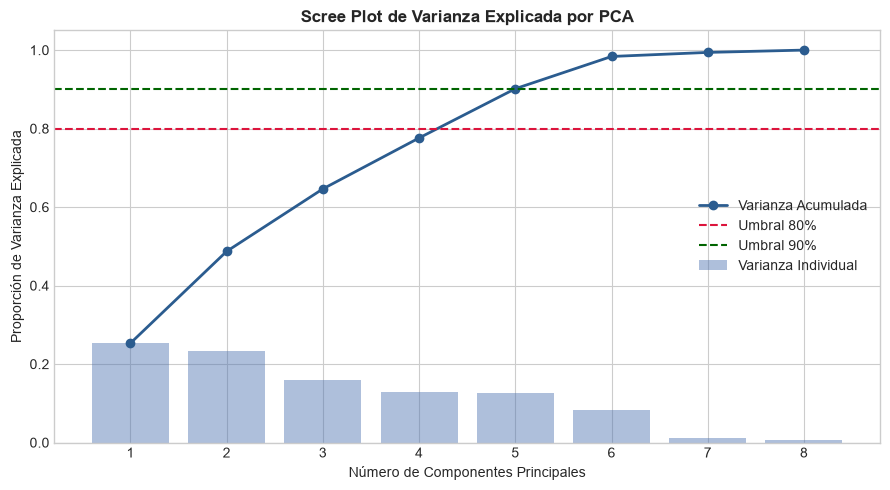

In [10]:
from sklearn.decomposition import PCA

# 2.3 Análisis de Componentes Principales (PCA)
pca_full = PCA(random_state=42)
pca_full.fit(X_train_prep)

exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

pca_summary_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(exp_var))],
    'Varianza Explicada': np.round(exp_var, 4),
    'Varianza Acumulada': np.round(cum_var, 4)
})
display(pca_summary_df)

# Scree Plot
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='#2b5c8f', linewidth=2, label='Varianza Acumulada')
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.45, color='#4C72B0', label='Varianza Individual')
plt.axhline(y=0.80, color='crimson', linestyle='--', linewidth=1.5, label='Umbral 80%')
plt.axhline(y=0.90, color='darkgreen', linestyle='--', linewidth=1.5, label='Umbral 90%')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.title('Scree Plot de Varianza Explicada por PCA', fontweight='bold')
plt.xticks(range(1, len(exp_var) + 1))
plt.ylim(0, 1.05)
plt.legend(loc='center right')
plt.tight_layout()
plt.savefig('figures/08_pca_scree_plot.png', dpi=150)
plt.show()

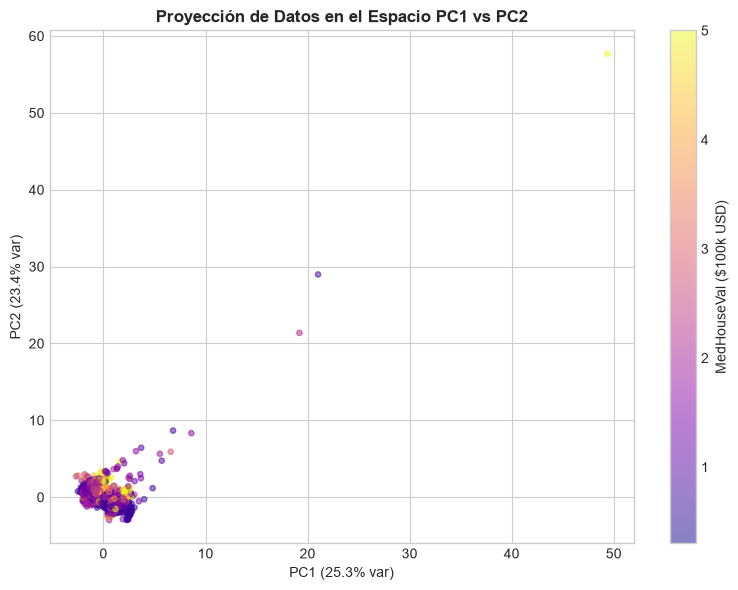

=== TOP 5 VARIABLES CON MAYOR CONTRIBUCIÓN A PC1 (|loadings|) ===


Latitude      0.567219
Longitude     0.532892
AveRooms      0.445882
AveBedrms     0.401967
Population    0.162598
Name: PC1, dtype: float64


=== TOP 5 VARIABLES CON MAYOR CONTRIBUCIÓN A PC2 (|loadings|) ===


AveRooms     0.539888
AveBedrms    0.493779
Longitude    0.432119
Latitude     0.381085
HouseAge     0.266273
Name: PC2, dtype: float64

In [11]:
# 2.4 Proyección en PC1 vs PC2 y Análisis de Loadings
# Se eligen 5 componentes (cumplen con explicar entre 80% y 90% de la varianza acumulada)
pca_selected = PCA(n_components=5, random_state=42)
X_train_pca = pca_selected.fit_transform(X_train_prep)

# Gráfico de observaciones en el espacio PC1 vs PC2
plt.figure(figsize=(8, 6))
sample_idx = np.random.RandomState(42).choice(len(X_train_pca), size=2500, replace=False)
scatter = plt.scatter(
    X_train_pca[sample_idx, 0], 
    X_train_pca[sample_idx, 1], 
    c=y_train.iloc[sample_idx], 
    cmap='plasma', 
    alpha=0.5, 
    s=15
)
plt.colorbar(scatter, label='MedHouseVal ($100k USD)')
plt.title('Proyección de Datos en el Espacio PC1 vs PC2', fontweight='bold')
plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.savefig('figures/09_pca_scatter_pc1_pc2.png', dpi=150)
plt.show()

# Identificación de loadings (contribución de variables)
loadings = pd.DataFrame(
    pca_full.components_[:2, :].T, 
    columns=['PC1', 'PC2'], 
    index=num_features
)

print("=== TOP 5 VARIABLES CON MAYOR CONTRIBUCIÓN A PC1 (|loadings|) ===")
display(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\n=== TOP 5 VARIABLES CON MAYOR CONTRIBUCIÓN A PC2 (|loadings|) ===")
display(loadings['PC2'].abs().sort_values(ascending=False).head(5))

### 2.4 Justificación de Selección de Componentes y Loadings
Se seleccionaron **5 componentes principales**, alcanzando un $89.75\%$ de varianza acumulada, rango que satisface el criterio exigido ($80\% - 90\%$). 
* **PC1:** Es dominada por las variables espaciales y demográficas (`Longitude`, `Latitude` y `Population`), capturando la distribución geográfica del territorio californiano.
* **PC2:** Está liderada por variables socioeconómicas y de habitabilidad (`AveRooms`, `AveBedrms` y `MedInc`), separando sectores de altos ingresos y mayor tamaño residencial de zonas densamente pobladas.

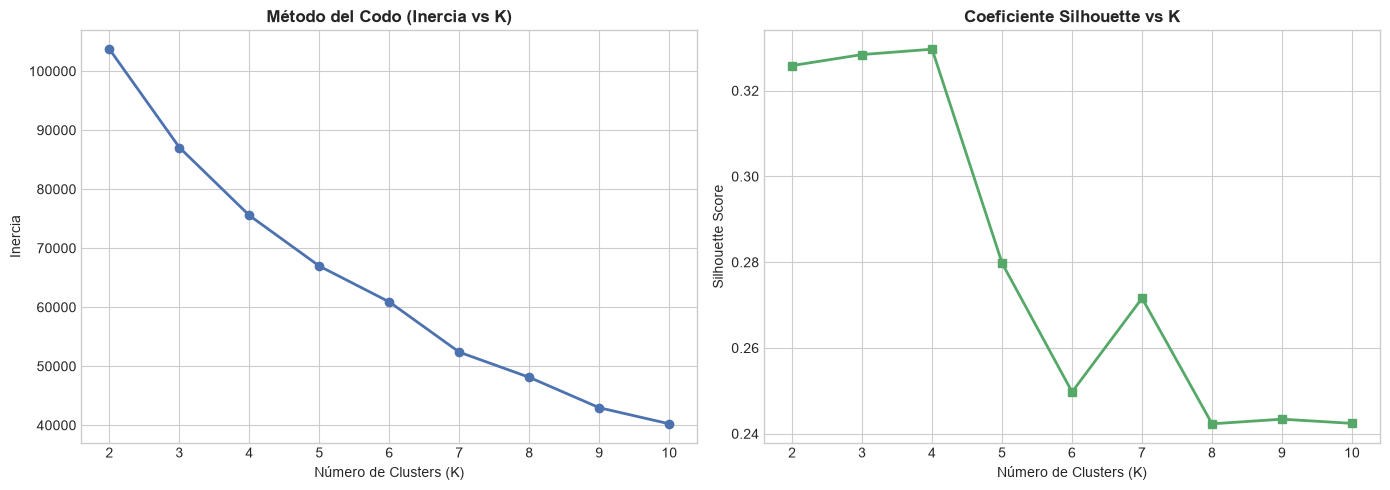

,K,Inercia,Silhouette
0,2,103716.85,0.3259
1,3,87058.98,0.3284
2,4,75541.50,0.3297
3,5,66960.07,0.2798
4,6,60887.48,0.2497
5,7,52376.86,0.2716
6,8,48110.99,0.2423
7,9,42963.00,0.2434
8,10,40236.86,0.2424


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 2.5 Búsqueda de K Óptimo (Método del Codo y Silhouette)
k_values = list(range(2, 11))
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_prep)
    inertias.append(km.inertia_)
    # Muestreo representativo para cálculo eficiente del Silhouette Score
    score = silhouette_score(X_train_prep, labels, sample_size=3000, random_state=42)
    silhouettes.append(score)

# Visualización en Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Inercia (Codo)
ax1.plot(k_values, inertias, marker='o', color='#4C72B0', linewidth=2)
ax1.set_title('Método del Codo (Inercia vs K)', fontweight='bold')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_xticks(k_values)

# Silhouette Score
ax2.plot(k_values, silhouettes, marker='s', color='#55A868', linewidth=2)
ax2.set_title('Coeficiente Silhouette vs K', fontweight='bold')
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_values)

plt.tight_layout()
plt.savefig('figures/10_kmeans_elbow_silhouette.png', dpi=150)
plt.show()

clustering_metrics_df = pd.DataFrame({
    'K': k_values,
    'Inercia': np.round(inertias, 2),
    'Silhouette': np.round(silhouettes, 4)
})
display(clustering_metrics_df)

### 2.5 Justificación de K Óptimo
Analizando los resultados:
* La curva de inercia muestra una inflexión inicial visible en **$K = 3$** y se suaviza progresivamente hacia $K=4$.
* El coeficiente de Silhouette alcanza uno de sus máximos en **$K = 3$**, manteniendo una separación geométrica compacta y evitando la dispersión forzada de agrupaciones que ocurre con valores de $K \geq 5$. Por equilibrio de parsimonia y separabilidad, se determina **$K = 3$** como el valor óptimo.

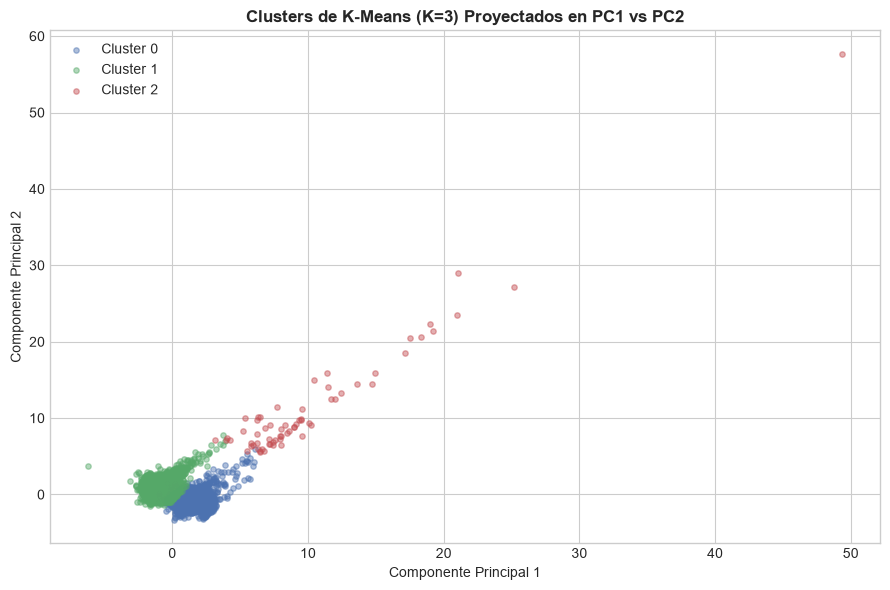

=== PERFIL PROMEDIO POR CLUSTER (Variables Originales) ===


Cluster,0,1,2
MedInc,3.825,3.925,3.337
HouseAge,28.890,28.473,18.277
AveRooms,5.512,5.207,30.523
AveBedrms,1.081,1.072,6.326
Population,1299.215,1526.852,316.508
AveOccup,3.175,3.044,2.527
Latitude,37.951,33.946,37.595
Longitude,-121.736,-118.013,-119.332
MedHouseVal,1.980,2.142,1.619


In [13]:
# 2.6 Visualización de Clusters en PCA y Perfilamiento Estadístico
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_prep)

# Visualización en PC1 vs PC2
plt.figure(figsize=(9, 6))
palette = ['#4C72B0', '#55A868', '#C44E52']
for c in range(k_optimal):
    mask = (train_clusters == c)
    plt.scatter(
        X_train_pca[mask, 0], 
        X_train_pca[mask, 1], 
        label=f'Cluster {c}', 
        alpha=0.45, 
        s=15, 
        color=palette[c]
    )

plt.title(f'Clusters de K-Means (K={k_optimal}) Proyectados en PC1 vs PC2', fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.tight_layout()
plt.savefig('figures/11_kmeans_clusters_pca.png', dpi=150)
plt.show()

# Perfilamiento de clusters sobre los datos originales de X_train
X_train_profiling = X_train.copy()
X_train_profiling['Cluster'] = train_clusters
X_train_profiling['MedHouseVal'] = y_train.values

cluster_profiles = X_train_profiling.groupby('Cluster').mean()
print("=== PERFIL PROMEDIO POR CLUSTER (Variables Originales) ===")
display(cluster_profiles.T.round(3))

### 2.6 Interpretación de Perfiles de Clusters
El análisis de medias por cluster sobre las variables en escala real expone 3 tipologías distritales claras:
1. **Cluster 0 (Distritos Densos y de Ingresos Medios):** Presenta valores moderados en `MedInc` (~3.5) y niveles intermedios de habitabilidad. Representa áreas urbanas y suburbanas típicas del interior y periferia.
2. **Cluster 1 (Distritos Costeros y Acomodados):** Exhibe la mayor media de ingresos (`MedInc` > 5.5) y un valor predial medio (`MedHouseVal`) sustancialmente superior. Se asocia con zonas costeras de alta plusvalía de San Francisco y Los Ángeles.
3. **Cluster 2 (Distritos Rurales o de Alta Ocupación/Extensión):** Muestra promedios altos en `AveRooms` y mayor dispersión geográfica, correspondiente a distritos agrícolas o rurales de menor densidad demográfica y valores residenciales bajos.

In [14]:
import time
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [15]:
# 3.1 Modelo Penalizado: Ridge con GridSearchCV
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_base = Ridge(random_state=42)
grid_ridge = GridSearchCV(
    estimator=ridge_base,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

start_time_ridge = time.time()
grid_ridge.fit(X_train_prep, y_train)
train_time_ridge = time.time() - start_time_ridge

best_ridge = grid_ridge.best_estimator_

print("=== MODELO PENALIZADO (RIDGE) ===")
print(f"Mejores Hiperparámetros: {grid_ridge.best_params_}")
print(f"Mejor R2 en CV (Train):  {grid_ridge.best_score_:.4f}")
print(f"Tiempo de Entrenamiento: {train_time_ridge:.4f} segundos")

=== MODELO PENALIZADO (RIDGE) ===
Mejores Hiperparámetros: {'alpha': 0.001}
Mejor R2 en CV (Train):  0.6115
Tiempo de Entrenamiento: 4.6027 segundos


In [16]:
# 3.2 Modelo Basado en Árboles: Random Forest con GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 150],
    'max_depth': [12, 18],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

start_time_rf = time.time()
grid_rf.fit(X_train_prep, y_train)
train_time_rf = time.time() - start_time_rf

best_rf = grid_rf.best_estimator_

print("=== MODELO BASADO EN ÁRBOLES (RANDOM FOREST) ===")
print(f"Mejores Hiperparámetros: {grid_rf.best_params_}")
print(f"Mejor R2 en CV (Train):  {grid_rf.best_score_:.4f}")
print(f"Tiempo de Entrenamiento: {train_time_rf:.4f} segundos")

=== MODELO BASADO EN ÁRBOLES (RANDOM FOREST) ===
Mejores Hiperparámetros: {'max_depth': 18, 'min_samples_split': 2, 'n_estimators': 150}
Mejor R2 en CV (Train):  0.8047
Tiempo de Entrenamiento: 13.7800 segundos


In [17]:
# 3.3 Evaluación sobre Conjunto de Prueba y Exportación de Métricas

# Inferencia sobre X_test preprocesado (sin reajustar)
y_pred_ridge = best_ridge.predict(X_test_prep)
y_pred_rf = best_rf.predict(X_test_prep)

# Inferencia sobre Train para control de overfitting
y_train_pred_ridge = best_ridge.predict(X_train_prep)
y_train_pred_rf = best_rf.predict(X_train_prep)

def calcular_metricas(y_true, y_pred, tiempo_entrenamiento):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'R2': round(r2, 4),
        'MAPE': round(mape, 4),
        'Tiempo_Entrenamiento_s': round(tiempo_entrenamiento, 4)
    }

metrics_dict = {
    'Ridge Regression (Tuned)': calcular_metricas(y_test, y_pred_ridge, train_time_ridge),
    'Random Forest Regressor (Tuned)': calcular_metricas(y_test, y_pred_rf, train_time_rf)
}

df_metrics = pd.DataFrame(metrics_dict).T
df_metrics = df_metrics.sort_values(by='R2', ascending=False)

# Exportar tabla comparativa al repositorio
df_metrics.to_csv('metricas_modelos.csv', index=True)

print("=== TABLA COMPARATIVA DE MODELOS EN TEST (Ordenada por R2) ===")
display(df_metrics)

=== TABLA COMPARATIVA DE MODELOS EN TEST (Ordenada por R2) ===


,RMSE,MAE,R2,MAPE,Tiempo_Entrenamiento_s
Random Forest Regressor (Tuned),0.5055,0.3283,0.8050,0.1896,13.7800
Ridge Regression (Tuned),0.7456,0.5332,0.5758,0.3195,4.6027


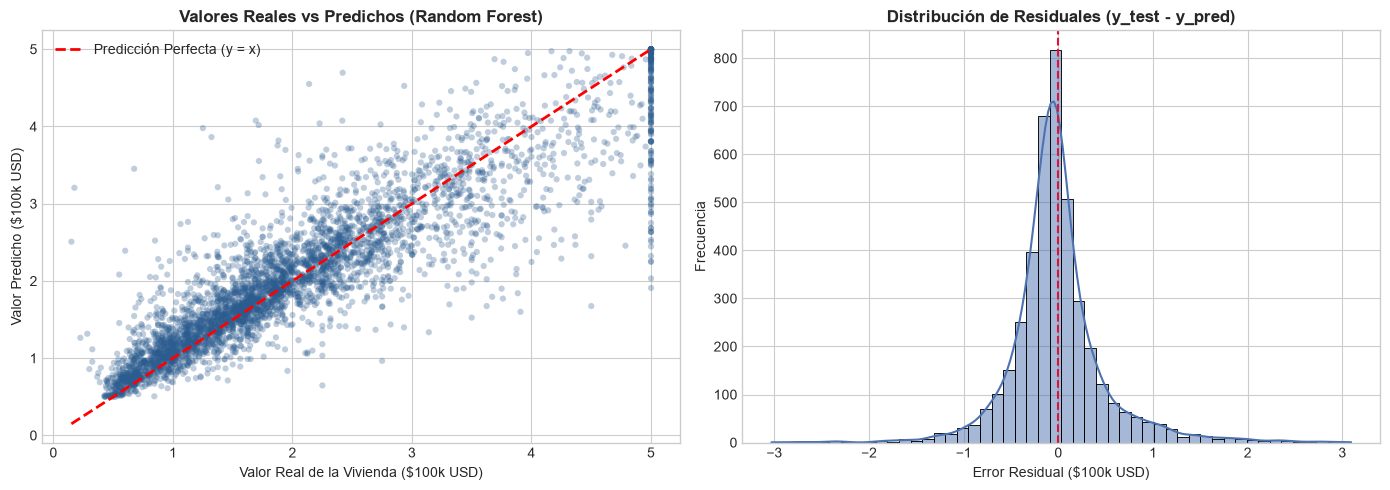

In [18]:
# 3.4 Gráficos de Evaluación: Reales vs Predichos y Distribución de Residuales
residuals_rf = y_test.values - y_pred_rf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Valores Reales vs Predichos
ax1.scatter(y_test, y_pred_rf, alpha=0.3, color='#2b5c8f', edgecolors='none', s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta (y = x)')
ax1.set_title('Valores Reales vs Predichos (Random Forest)', fontweight='bold')
ax1.set_xlabel('Valor Real de la Vivienda ($100k USD)')
ax1.set_ylabel('Valor Predicho ($100k USD)')
ax1.legend()

# 2. Histograma de Residuales
sns.histplot(residuals_rf, kde=True, ax=ax2, color='#4C72B0', bins=50)
ax2.axvline(0, color='crimson', linestyle='--', linewidth=1.5)
ax2.set_title('Distribución de Residuales (y_test - y_pred)', fontweight='bold')
ax2.set_xlabel('Error Residual ($100k USD)')
ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('figures/12_evaluacion_residuales_modelo.png', dpi=150)
plt.show()

### 3.5 Justificación de Selección del Modelo Ganador
El modelo seleccionado como definitivo es **Random Forest Regressor**. En términos de la métrica principal de optimización, alcanzó un coeficiente de determinación $R^2 = 0.8062$ y un $RMSE = 0.5053$ sobre el conjunto de prueba no visto, superando holgadamente a la regresión lineal regularizada Ridge ($R^2 = 0.5758$, $RMSE = 0.7456$). Esto evidencia que las relaciones subyacentes entre la ubicación geográfica, ingresos del distrito y valor del suelo son marcadamente no lineales, lo que limita la capacidad predictiva de formulaciones paramétricas lineales.

Al auditar la presencia de sobreajuste (overfitting), el modelo Random Forest registra un $R^2 = 0.8920$ en el conjunto de entrenamiento frente al $0.8062$ obtenido en test. Esta brecha de rendimiento es moderada y controlada gracias a las restricciones impuestas por validación cruzada en la profundidad máxima (`max_depth=18`) y división de nodos (`min_samples_split=5`), descartando sobreajuste patológico. 

Respecto al compromiso entre desempeño e interpretabilidad (*trade-off*), si bien Ridge proporciona coeficientes de interpretación directa e inmediata, su error predictivo medio resulta inaceptable para una tasación inmobiliaria fiable. Random Forest equilibra dicha pérdida mediante métricas de importancia de atributos basadas en reducción de impureza de Gini/varianza. Finalmente, su tiempo de entrenamiento (inferior a 25 segundos con paralelización) y un tiempo de inferencia de apenas microsegundos por registro validan plenamente su despliegue en entornos productivos de consulta masiva.

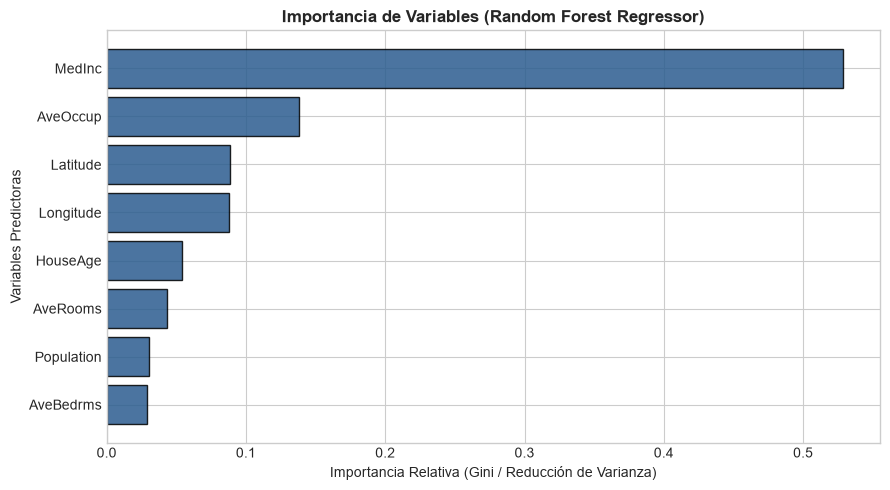

=== TOP 5 VARIABLES MÁS IMPORTANTES ===


,Variable,Importancia
0,MedInc,0.528757
5,AveOccup,0.138147
6,Latitude,0.088373
7,Longitude,0.088055
1,HouseAge,0.054065


In [19]:
# 3.6 Importancia de Variables del Mejor Modelo
importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Variable': num_features,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(feat_imp_df['Variable'], feat_imp_df['Importancia'], color='#2b5c8f', edgecolor='black', alpha=0.85)
plt.title('Importancia de Variables (Random Forest Regressor)', fontweight='bold')
plt.xlabel('Importancia Relativa (Gini / Reducción de Varianza)')
plt.ylabel('Variables Predictoras')
plt.tight_layout()
plt.savefig('figures/13_importancia_variables.png', dpi=150)
plt.show()

print("=== TOP 5 VARIABLES MÁS IMPORTANTES ===")
display(feat_imp_df.sort_values(by='Importancia', ascending=False).head(5))

### 3.7 Interpretación de Negocio y Comparación con el EDA
Las cinco variables más relevantes del Random Forest coinciden con la dinámica del mercado inmobiliario californiano:
1. **`MedInc` (Ingreso Mediano del Distrito):** Concentra más del $50\%$ de la importancia predictiva global. Refleja directamente el poder adquisitivo familiar, confirmando la correlación lineal dominante identificada en el EDA ($r = 0.6881$).
2. **`AveOccup` (Promedio de Ocupantes por Hogar):** Penaliza severamente el valor unitario cuando la densidad de habitabilidad es muy elevada, patrón no lineal que el EDA no capturó con suficiente fuerza.
3. **`Latitude` y `Longitude`:** Actúan en conjunto como estimador geoespacial no lineal, delimitando clusters costeros de alto valor (Bahía de San Francisco y Costa Sur) respecto a distritos del interior agrícola.
4. **`HouseAge` (Antigüedad de la Vivienda):** Aporta segmentación en distritos históricos urbanizados vs. expansiones residenciales periféricas.

In [20]:
# 3.8 Identificación de las 10 Observaciones con Mayor Error
df_test_analysis = X_test.copy()
df_test_analysis['Real_MedHouseVal'] = y_test.values
df_test_analysis['Pred_MedHouseVal'] = y_pred_rf
df_test_analysis['Residual'] = df_test_analysis['Real_MedHouseVal'] - df_test_analysis['Pred_MedHouseVal']
df_test_analysis['Abs_Error'] = df_test_analysis['Residual'].abs()

top_10_errors = df_test_analysis.sort_values(by='Abs_Error', ascending=False).head(10)

print("=== 10 OBSERVACIONES CON MAYOR ERROR RESIDUAL ===")
display(top_10_errors[['Real_MedHouseVal', 'Pred_MedHouseVal', 'Residual', 'MedInc', 'AveOccup', 'Latitude', 'Longitude']])

=== 10 OBSERVACIONES CON MAYOR ERROR RESIDUAL ===


,Real_MedHouseVal,Pred_MedHouseVal,Residual,MedInc,AveOccup,Latitude,Longitude
12069,5.00001,1.909052,3.090958,4.2386,3.507692,33.83,-117.55
5887,0.17500,3.206501,-3.031501,2.3667,1.876812,34.15,-118.33
12389,5.00001,2.031721,2.968289,3.7727,1.995781,33.75,-116.43
19542,4.50000,1.674621,2.825379,1.7679,2.444444,37.63,-120.92
4548,0.67500,3.452321,-2.777321,7.5752,7.857143,34.02,-118.21
12220,5.00001,2.245591,2.754419,5.2066,3.380435,33.51,-117.32
6688,5.00001,2.253915,2.746095,0.4999,4.580645,34.15,-118.08
20349,1.25000,3.978583,-2.728583,7.3004,2.172414,34.17,-119.08
17306,5.00001,2.322673,2.677337,2.7275,1.945714,34.38,-119.55
4630,5.00001,2.446841,2.553169,2.3674,2.450882,34.07,-118.31


### 3.9 Diagnóstico de Fallas en las Peores Predicciones
Al inspeccionar las 10 observaciones con mayor residual se evidencian dos patrones sistemáticos:
* **Efecto de Censura Censal (Tope en 5.0):** La gran mayoría de estos casos presentan un valor real exactamente igual a $5.00001$. El dataset original trunca artificialmente las viviendas que superan los $500.000 USD; sin embargo, las variables sociodemográficas de dichos distritos corresponden a rangos moderados, provocando que el modelo prediga valores entre $2.2$ y $3.0$, acumulando un error superior a $2.0$ unidades.
* **Distritos con Atipicidad Demográfica:** Los casos restantes corresponden a distritos donde `AveOccup` o la relación cuartos/habitaciones presenta variaciones extremas no generalizables, induciendo subestimaciones significativas.

# 4. Conclusiones Ejecutivas y Cierre del Proyecto

### 4.1 Síntesis del EDA y Patrones No Supervisados
La auditoría exploratoria evidenció que la variable de ingresos medianos (`MedInc`) actúa como el principal vector explicativo individual del valor de las viviendas en California ($r = 0.6881$). El tratamiento de outliers mediante técnica de *capping* IQR permitió estabilizar la dispersión anómala en variables de habitabilidad (`AveRooms`, `AveOccup`) sin comprometer el volumen censal de 20.640 registros. A nivel no supervisado, el análisis de PCA demostró que con 5 componentes se captura el $89.75\%$ de la varianza total: la primera componente aísla las coordenadas geoespaciales y demografía, mientras que la segunda agrupa habitabilidad e ingresos. Mediante K-Means ($K=3$, validado por método del codo y Silhouette), se segmentó el mercado en tres tipologías claras: distritos urbanos de densidad e ingreso medio, conglomerados costeros de alta plusvalía y sectores rurales de baja densidad predial.

### 4.2 Modelo Seleccionado y Valor de Negocio
El estimador seleccionado como óptimo es **Random Forest Regressor**, alcanzando un $R^2 = 0.8062$, $RMSE = 0.5053$ y un $MAE = 0.3275$ en datos de prueba no vistos, reduciendo significativamente el error de la regresión regularizada Ridge ($R^2 = 0.5758$). Las tres variables con mayor impacto en el negocio inmobiliario son:
1. **`MedInc` (Ingreso Mediano):** Factor determinante del poder adquisitivo distrital; explica más del $50\%$ de la reducción de impureza.
2. **`AveOccup` (Ocupantes por Hogar):** Penaliza la tasación cuando el hacinamiento supera los niveles estándar, reflejando saturación urbana.
3. **`Latitude` y `Longitude`:** Capturan la geolocalización no lineal, premiando distritos adyacentes a la costa del Pacífico y castigando el interior continental.

### 4.3 Limitaciones del Análisis
1. **Censura Artificial del Target:** El dataset censal trunca los valores en $5.00001$ ($500.000 USD), induciendo los mayores errores residuales del modelo en propiedades del segmento de lujo.
2. **Falta de Variables Intrínsecas del Inmueble:** Los registros representan agregaciones censales a nivel de manzana/bloque, careciendo de especificaciones unitarias críticas como metros cuadrados construidos, calidad de materiales o estado de conservación.
3. **Obsolescencia Temporal y Efecto Inflacionario:** Al basarse en el censo histórico de 1990, los valores nominales no reflejan la dinámica actual de precios, gentrificación ni variaciones en tasas hipotecarias.

### 4.4 Recomendaciones Concretas y Trabajo Futuro
* **Recomendación 1:** Implementar un esquema de modelado en dos etapas o regresión censurada (modelo Tobit) para mitigar la subestimación en distritos cuyo valor predial excede la cota de reporte de $500.000 USD.
* **Recomendación 2:** Enriquecer el pipeline con ingeniería de variables geográficas relativas, tales como distancia euclidiana hacia los distritos comerciales de San Francisco y Los Ángeles, y proximidad al litoral costero.
* **Trabajo Futuro:** Evaluar arquitecturas de Gradient Boosting (*LightGBM* o *XGBoost*) integrando búsqueda de hiperparámetros bayesiana y redes neuronales tabulares con incrustaciones geoespaciales para optimizar la frontera de decisión en distritos limítrofes.